# Sphere Spectrum Under Discretization and Local Deformation

This notebook studies how Laplace-Beltrami spectra and eigenfunctions behave in two scenarios:

1. changing the **discretization** of a sphere (number of sampled points/faces),
2. changing a **localized deformation** (a Gaussian blob) while keeping connectivity fixed.

For the deformation case, we also compute an area-based shape-difference operator
$$S_D = C^\top C$$
and inspect its first distortion direction on the reference sphere.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from plot_utils import setup_pyvista, show_mesh, show_multiple_scalars
from scipy.spatial import ConvexHull

from geomfum.convert import FmFromP2pConverter
from geomfum.shape import TriangleMesh

setup_pyvista()

In [2]:
def make_sphere_mesh(n_points, seed=0):
    rng = np.random.default_rng(seed)
    pts = rng.standard_normal((n_points, 3))
    pts /= np.linalg.norm(pts, axis=1, keepdims=True)

    hull = ConvexHull(pts)
    vertices = np.asarray(hull.points, dtype=float)
    faces = np.asarray(hull.simplices, dtype=int)
    return TriangleMesh(vertices=vertices, faces=faces)


def deform_blob(vertices, center=(0.0, 0.0, 1.0), amplitude=0.0, sigma=0.30):
    center = np.asarray(center, dtype=float)
    center /= np.linalg.norm(center)

    v = np.asarray(vertices, dtype=float)
    v_hat = v / np.linalg.norm(v, axis=1, keepdims=True)

    ang = np.arccos(np.clip(v_hat @ center, -1.0, 1.0))
    weight = np.exp(-(ang**2) / (2.0 * sigma**2))

    return v * (1.0 + amplitude * weight[:, None])


def compute_spectrum(mesh, k=40):
    vals, vecs = mesh.laplacian.find_spectrum(spectrum_size=k, set_as_basis=True)
    return vals, vecs

## 1) Single discretized sphere: Laplacian and spectrum

In [3]:
base = make_sphere_mesh(n_points=1200, seed=1)
base_vals, base_vecs = compute_spectrum(base, k=40)
L, M = base.laplacian.find()

print(f"Vertices: {base.n_vertices}, Faces: {base.n_faces}")
print(f"Laplacian shape: {L.shape}, Mass matrix shape: {M.shape}")
print(f"First 6 eigenvalues: {np.round(base_vals[:6], 6)}")

Vertices: 1200, Faces: 2396
Laplacian shape: (1200, 1200), Mass matrix shape: (1200, 1200)
First 6 eigenvalues: [-0.        1.998244  1.999242  2.001025  5.944328  5.95516 ]


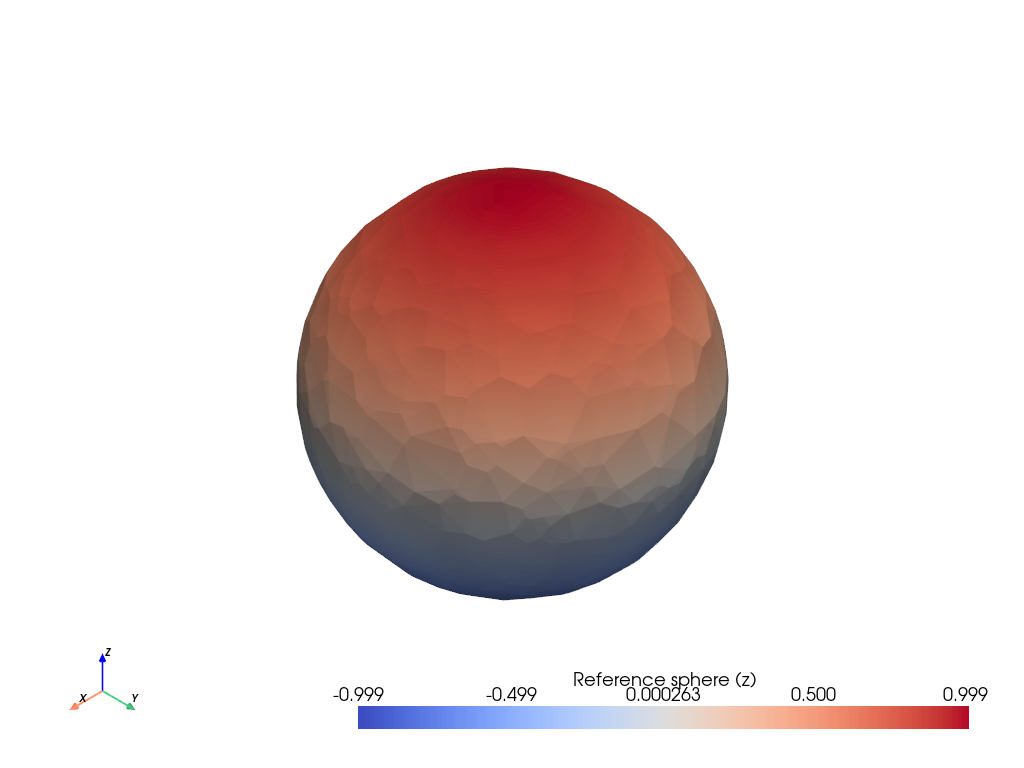

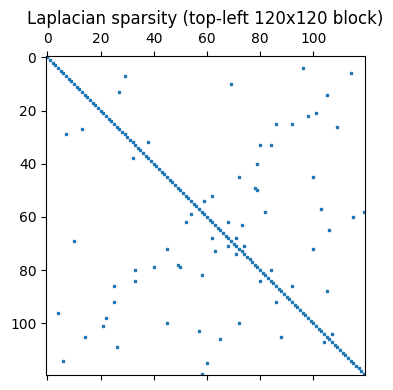

In [4]:
show_mesh(
    base.vertices,
    base.faces,
    scalars=base.vertices[:, 2],
    scalar_name="Reference sphere (z)",
    cmap="coolwarm",
    smooth=False,
)

plt.figure(figsize=(6, 4))
plt.spy(L[:120, :120], markersize=2)
plt.title("Laplacian sparsity (top-left 120x120 block)")
plt.tight_layout()
plt.show()

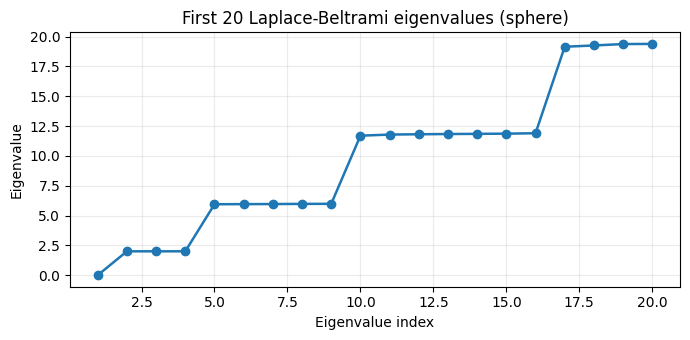

In [5]:
plt.figure(figsize=(7, 3.5))
plt.plot(np.arange(1, 21), base_vals[:20], "o-", lw=1.8)
plt.xlabel("Eigenvalue index")
plt.ylabel("Eigenvalue")
plt.title("First 20 Laplace-Beltrami eigenvalues (sphere)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

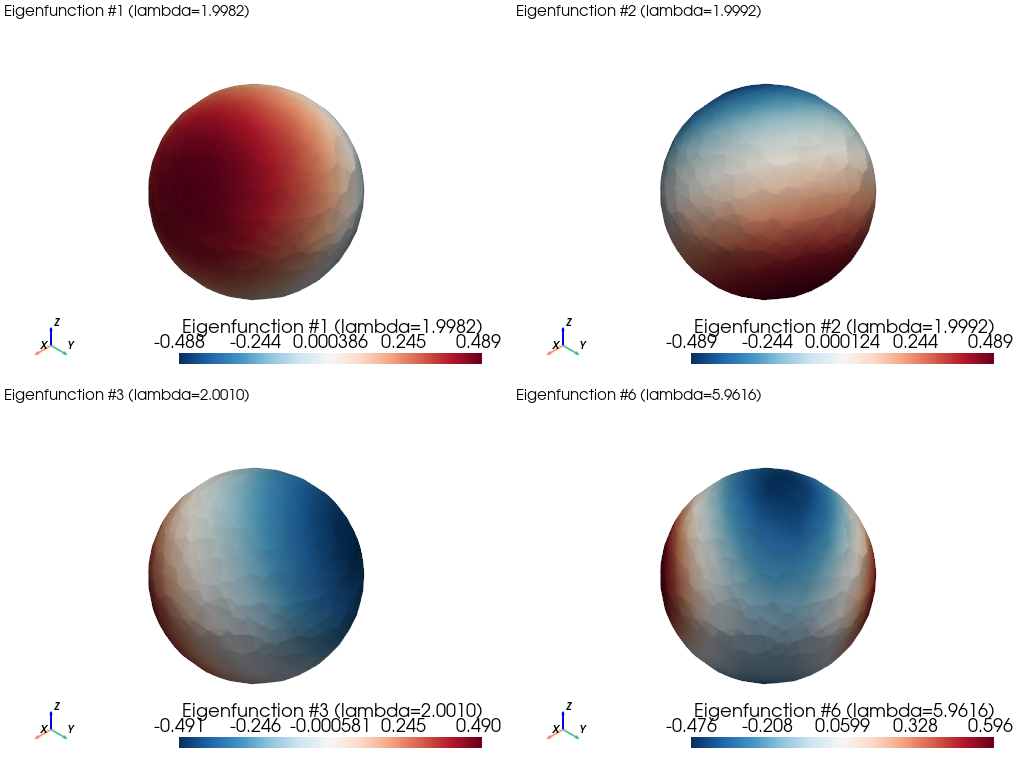

In [6]:
eig_ids = [1, 2, 3, 6]
show_multiple_scalars(
    base.vertices,
    base.faces,
    {
        f"Eigenfunction #{idx} (lambda={base_vals[idx]:.4f})": base_vecs[:, idx]
        for idx in eig_ids
    },
    cmap="RdBu_r",
    smooth=False,
    n_cols=2,
)

## 2a) Parameter study: discretization (number of sampled points/faces)

In [7]:
n_points_list = [300, 600, 1200, 2400]
spectra_by_n = {}
counts = {}

for n in n_points_list:
    mesh_n = make_sphere_mesh(n_points=n, seed=2)
    vals_n, _ = compute_spectrum(mesh_n, k=30)
    spectra_by_n[n] = vals_n
    counts[n] = (mesh_n.n_vertices, mesh_n.n_faces)

for n in n_points_list:
    nv, nf = counts[n]
    print(f"n={n:4d} -> vertices={nv:4d}, faces={nf:4d}")

n= 300 -> vertices= 300, faces= 596
n= 600 -> vertices= 600, faces=1196
n=1200 -> vertices=1200, faces=2396
n=2400 -> vertices=2400, faces=4796


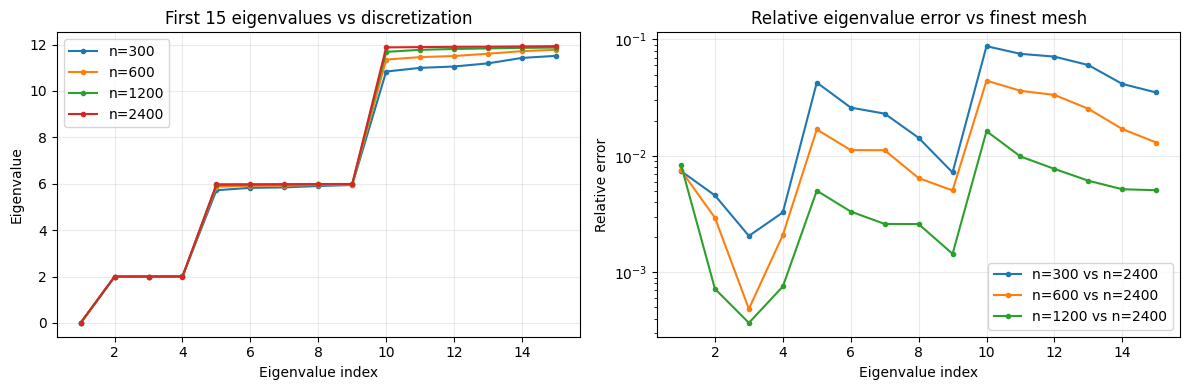

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for n in n_points_list:
    axes[0].plot(np.arange(1, 16), spectra_by_n[n][:15], "o-", ms=3, label=f"n={n}")

axes[0].set_title("First 15 eigenvalues vs discretization")
axes[0].set_xlabel("Eigenvalue index")
axes[0].set_ylabel("Eigenvalue")
axes[0].grid(alpha=0.25)
axes[0].legend()

n_ref = max(n_points_list)
ref = spectra_by_n[n_ref]
for n in n_points_list[:-1]:
    rel_err = np.abs(spectra_by_n[n][:15] - ref[:15]) / np.maximum(
        np.abs(ref[:15]), 1e-12
    )
    axes[1].plot(np.arange(1, 16), rel_err, "o-", ms=3, label=f"n={n} vs n={n_ref}")

axes[1].set_yscale("log")
axes[1].set_title("Relative eigenvalue error vs finest mesh")
axes[1].set_xlabel("Eigenvalue index")
axes[1].set_ylabel("Relative error")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

## 2b) Parameter study: local blob deformation

Here we keep the same connectivity and only change vertices:
$$x_\alpha(v) = (1 + \alpha \, w(v)) x(v), \qquad w(v) = \exp\left(-\frac{\theta(v,c)^2}{2\sigma^2}\right),$$
where $c$ is the blob center and $\theta(v,c)$ is angular distance on the sphere.

In [9]:
mesh_ref = make_sphere_mesh(n_points=1800, seed=7)
k_sd = 40
ref_vals, _ = compute_spectrum(mesh_ref, k=k_sd)

alphas = [0.00, 0.05, 0.10, 0.20, 0.35]
blob_sigma = 0.32

fm_conv = FmFromP2pConverter()
p2p_identity = np.arange(mesh_ref.n_vertices)

spectra_by_alpha = {}
lead_mu_by_alpha = {}
lead_field_by_alpha = {}

for alpha in alphas:
    deformed_vertices = deform_blob(
        mesh_ref.vertices,
        center=(0.0, 0.0, 1.0),
        amplitude=alpha,
        sigma=blob_sigma,
    )
    mesh_def = TriangleMesh(vertices=deformed_vertices, faces=mesh_ref.faces)

    vals_def, _ = compute_spectrum(mesh_def, k=k_sd)
    spectra_by_alpha[alpha] = vals_def

    C = fm_conv(p2p_identity, mesh_ref.basis, mesh_def.basis)
    S_D = C.T @ C

    mu, U = np.linalg.eigh(S_D)
    order = np.argsort(np.abs(mu))[::-1]
    i0 = order[0]

    lead_mu_by_alpha[alpha] = mu[i0]
    lead_field = mesh_ref.basis.vecs @ U[:, i0]
    lead_field_by_alpha[alpha] = lead_field
print("Computed deformation sweep for alphas:", alphas)

Computed deformation sweep for alphas: [0.0, 0.05, 0.1, 0.2, 0.35]


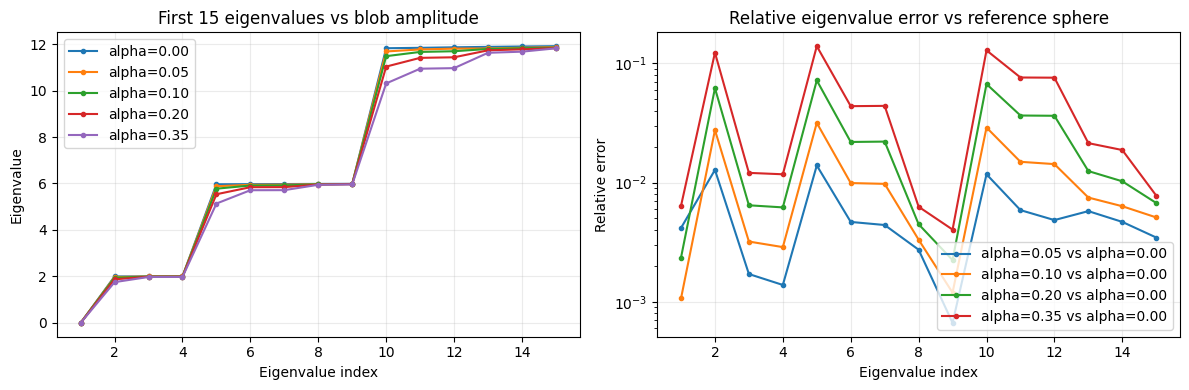

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for alpha in alphas:
    axes[0].plot(
        np.arange(1, 16),
        spectra_by_alpha[alpha][:15],
        "o-",
        ms=3,
        label=f"alpha={alpha:.2f}",
    )

axes[0].set_title("First 15 eigenvalues vs blob amplitude")
axes[0].set_xlabel("Eigenvalue index")
axes[0].set_ylabel("Eigenvalue")
axes[0].grid(alpha=0.25)
axes[0].legend()

alpha_ref = min(alphas)
ref = spectra_by_alpha[alpha_ref]
for alpha in alphas:
    if alpha == alpha_ref:
        continue
    rel_err = np.abs(spectra_by_alpha[alpha][:15] - ref[:15]) / np.maximum(
        np.abs(ref[:15]), 1e-12
    )
    axes[1].plot(
        np.arange(1, 16),
        rel_err,
        "o-",
        ms=3,
        label=f"alpha={alpha:.2f} vs alpha={alpha_ref:.2f}",
    )

axes[1].set_yscale("log")
axes[1].set_title("Relative eigenvalue error vs reference sphere")
axes[1].set_xlabel("Eigenvalue index")
axes[1].set_ylabel("Relative error")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

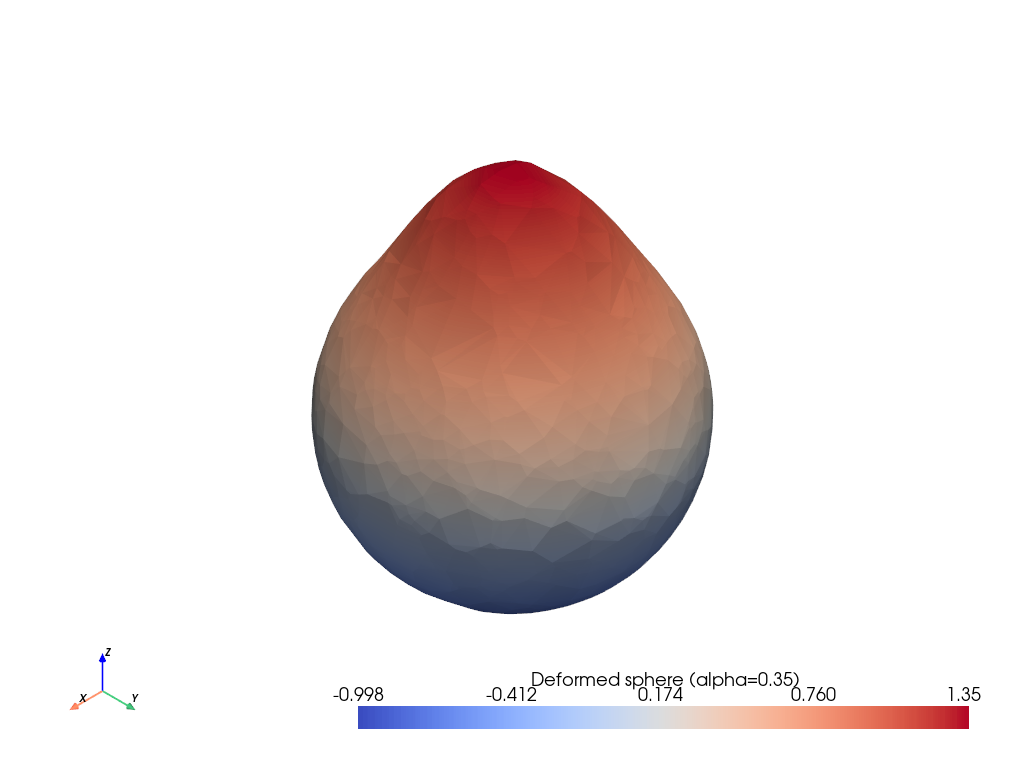

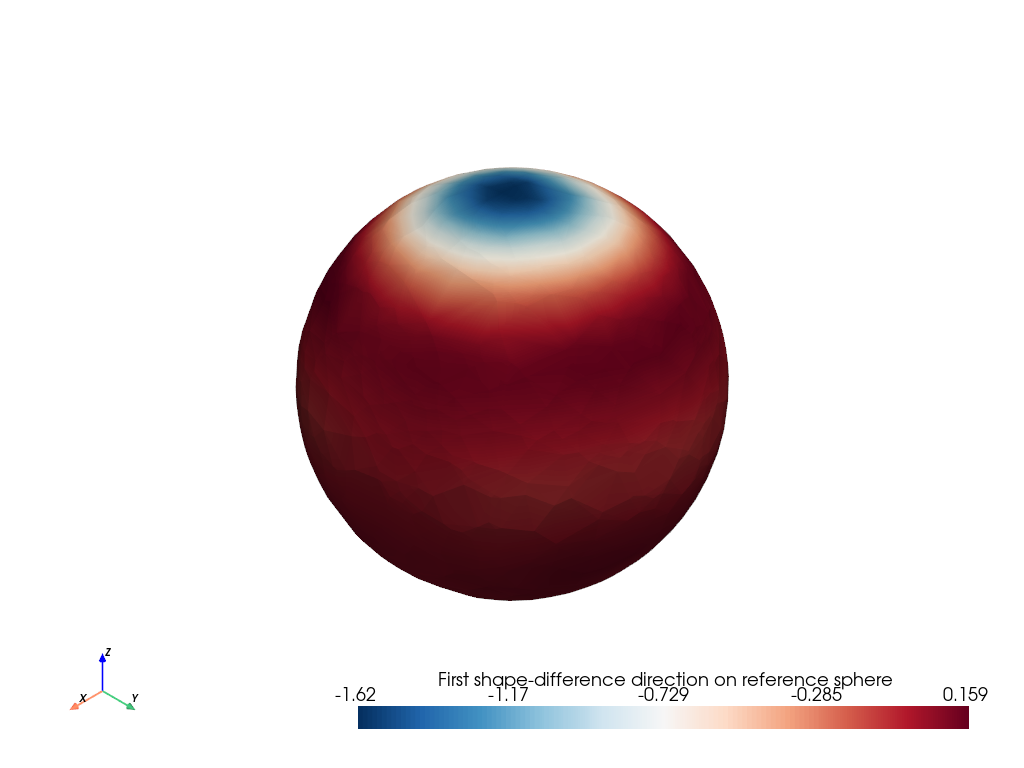

In [11]:
alpha_show = alphas[-1]
field = lead_field_by_alpha[alpha_show]

v_show = deform_blob(mesh_ref.vertices, amplitude=alpha_show, sigma=blob_sigma)
show_mesh(
    v_show,
    mesh_ref.faces,
    scalars=v_show[:, 2],
    scalar_name=f"Deformed sphere (alpha={alpha_show})",
    cmap="coolwarm",
    smooth=False,
)

show_mesh(
    mesh_ref.vertices,
    mesh_ref.faces,
    scalars=field,
    scalar_name="First shape-difference direction on reference sphere",
    cmap="RdBu_r",
    smooth=False,
)

## Interpretation notes

- Increasing discretization usually stabilizes low-frequency eigenvalues first, while higher modes converge more slowly.
- Localized blob deformation perturbs eigenvalues and can split near-multiplicities on the sphere.
- The first direction of $S_D = C^\top C$ highlights where deformation is most spectrally visible on the reference shape.

## Interactive exploration

Use the widgets below to move each parameter and inspect geometric and spectral effects in real time.

In [12]:
from pathlib import Path

import ipywidgets as widgets
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Cache meshes/spectra once so slider interaction stays responsive.
mesh_by_n = {}
for n in n_points_list:
    if n not in mesh_by_n:
        mesh_n = make_sphere_mesh(n_points=n, seed=2)
        vals_n, _ = compute_spectrum(mesh_n, k=30)
        mesh_by_n[n] = mesh_n
        spectra_by_n[n] = vals_n

html_dir = Path("docs/_static/interactive")
html_dir.mkdir(parents=True, exist_ok=True)


def mesh3d_trace(
    vertices, faces, intensity, name="", colorscale="RdBu", showscale=True
):
    return go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        intensity=intensity,
        colorscale=colorscale,
        showscale=showscale,
        colorbar=dict(len=0.65),
        name=name,
        opacity=1.0,
    )


def show_discretization_interactive(n_points, export_html=False):
    mesh_n = mesh_by_n[n_points]

    fig = make_subplots(
        rows=1,
        cols=2,
        specs=[[{"type": "scene"}, {"type": "xy"}]],
        subplot_titles=(f"Sphere mesh (n={n_points})", "First 15 eigenvalues"),
        horizontal_spacing=0.08,
    )

    fig.add_trace(
        mesh3d_trace(
            mesh_n.vertices,
            mesh_n.faces,
            mesh_n.vertices[:, 2],
            colorscale="RdBu",
            showscale=True,
        ),
        row=1,
        col=1,
    )

    for n in n_points_list:
        alpha_line = 1.0 if n == n_points else 0.35
        width_line = 2.5 if n == n_points else 1.2
        fig.add_trace(
            go.Scatter(
                x=np.arange(1, 16),
                y=spectra_by_n[n][:15],
                mode="lines+markers",
                marker=dict(size=5),
                line=dict(width=width_line),
                opacity=alpha_line,
                name=f"n={n}",
            ),
            row=1,
            col=2,
        )

    fig.update_scenes(aspectmode="data", camera=dict(eye=dict(x=1.5, y=1.5, z=1.0)))
    fig.update_xaxes(title_text="Eigenvalue index", row=1, col=2)
    fig.update_yaxes(title_text="Eigenvalue", row=1, col=2)
    fig.update_layout(height=520, width=1100, template="plotly_white", showlegend=True)

    fig.show()

    if export_html:
        out = html_dir / f"discretization_n{n_points}.html"
        fig.write_html(out, include_plotlyjs="cdn")
        print(f"Saved interactive HTML: {out}")


widgets.interact(
    show_discretization_interactive,
    n_points=widgets.SelectionSlider(
        options=n_points_list,
        value=n_points_list[0],
        description="n points",
        continuous_update=False,
    ),
    export_html=widgets.Checkbox(value=False, description="export html"),
);

interactive(children=(SelectionSlider(continuous_update=False, description='n points', options=(300, 600, 1200…

In [13]:
# Cache deformation results for interactive browsing.
deformation_cache = {}


def deformation_state(alpha):
    alpha = float(alpha)
    key = round(alpha, 4)
    if key in deformation_cache:
        return deformation_cache[key]

    deformed_vertices = deform_blob(
        mesh_ref.vertices,
        center=(0.0, 0.0, 1.0),
        amplitude=alpha,
        sigma=blob_sigma,
    )
    mesh_def = TriangleMesh(vertices=deformed_vertices, faces=mesh_ref.faces)
    vals_def, _ = compute_spectrum(mesh_def, k=k_sd)

    C = fm_conv(p2p_identity, mesh_ref.basis, mesh_def.basis)
    S_D = C.T @ C

    mu, U = np.linalg.eigh(S_D)
    order = np.argsort(np.abs(mu))[::-1]
    i0 = order[0]
    lead_field = mesh_ref.basis.vecs @ U[:, i0]

    payload = {
        "vertices": deformed_vertices,
        "vals": vals_def,
        "S_D": S_D,
        "mu0": mu[i0],
        "lead_field": lead_field,
    }
    deformation_cache[key] = payload
    return payload


def show_deformation_interactive(alpha, export_html=False):
    state = deformation_state(alpha)
    vals_def = state["vals"]
    S_D = state["S_D"]

    rel_err = np.abs(vals_def[:15] - ref_vals[:15]) / np.maximum(
        np.abs(ref_vals[:15]), 1e-12
    )

    fig = make_subplots(
        rows=2,
        cols=2,
        specs=[
            [{"type": "scene"}, {"type": "xy", "secondary_y": True}],
            [{"type": "xy"}, {"type": "scene"}],
        ],
        subplot_titles=(
            f"Deformed sphere (alpha={alpha:.2f})",
            "Spectrum vs reference",
            "Shape-difference operator S_D",
            f"First SD direction (mu={state['mu0']:.3f})",
        ),
        horizontal_spacing=0.08,
        vertical_spacing=0.12,
    )

    fig.add_trace(
        mesh3d_trace(
            state["vertices"],
            mesh_ref.faces,
            state["vertices"][:, 2],
            colorscale="RdBu",
            showscale=True,
        ),
        row=1,
        col=1,
    )

    fig.add_trace(
        go.Scatter(
            x=np.arange(1, 16),
            y=ref_vals[:15],
            mode="lines+markers",
            marker=dict(size=5),
            line=dict(width=1.6),
            name="reference",
        ),
        row=1,
        col=2,
        secondary_y=False,
    )
    fig.add_trace(
        go.Scatter(
            x=np.arange(1, 16),
            y=vals_def[:15],
            mode="lines+markers",
            marker=dict(size=5),
            line=dict(width=2.1),
            name=f"alpha={alpha:.2f}",
        ),
        row=1,
        col=2,
        secondary_y=False,
    )
    fig.add_trace(
        go.Scatter(
            x=np.arange(1, 16),
            y=rel_err,
            mode="lines+markers",
            marker=dict(size=5, symbol="diamond"),
            line=dict(width=1.4, dash="dash", color="crimson"),
            name="relative error",
        ),
        row=1,
        col=2,
        secondary_y=True,
    )

    fig.add_trace(
        go.Heatmap(
            z=S_D,
            colorscale="RdBu",
            colorbar=dict(len=0.35, y=0.23),
            name="S_D",
        ),
        row=2,
        col=1,
    )

    fig.add_trace(
        mesh3d_trace(
            mesh_ref.vertices,
            mesh_ref.faces,
            state["lead_field"],
            colorscale="RdBu",
            showscale=True,
        ),
        row=2,
        col=2,
    )

    fig.update_scenes(aspectmode="data", camera=dict(eye=dict(x=1.45, y=1.45, z=0.95)))
    fig.update_xaxes(title_text="Eigenvalue index", row=1, col=2)
    fig.update_yaxes(title_text="Eigenvalue", row=1, col=2, secondary_y=False)
    fig.update_yaxes(title_text="Relative error", row=1, col=2, secondary_y=True)
    fig.update_xaxes(title_text="Mode index", row=2, col=1)
    fig.update_yaxes(title_text="Mode index", row=2, col=1)

    fig.update_layout(height=900, width=1200, template="plotly_white", showlegend=True)
    fig.show()

    if export_html:
        out = html_dir / f"deformation_alpha_{alpha:.2f}.html"
        fig.write_html(out, include_plotlyjs="cdn")
        print(f"Saved interactive HTML: {out}")


widgets.interact(
    show_deformation_interactive,
    alpha=widgets.FloatSlider(
        value=0.0,
        min=0.0,
        max=0.40,
        step=0.02,
        description="alpha",
        readout_format=".2f",
        continuous_update=False,
    ),
    export_html=widgets.Checkbox(value=False, description="export html"),
);

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='alpha', max=0.4, step=0.02)…